![data](https://storage.googleapis.com/kaggle-datasets-images/7714230/12337688/a00eb373e4b69662d751facf5b847d14/dataset-cover.png?t=2025-07-01-07-46-53)

# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings('ignore')

# Load File

In [4]:
df=pd.read_csv('../Data/raw_salary.csv')

# Data Analysis

Here, we will look for any discrepancies and correct any issues we find.

## 1> Getting shape of the dataset

`df.shape`

In [5]:
df.shape

(48842, 15)

Dataset has *48k rows and 14 columns*.<br>
The dataset is of descet size

## 2> Looking at data [just a vauge sense of what our dataset looks like]

`df.head()`

In [6]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


| **Variable Name** | **Role**    | **Type**       | **Demographic**    | **Description**                                               | **Units** | **Missing Values** |
|-------------------|-------------|----------------|--------------------|---------------------------------------------------------------|-----------|--------------------|
| <span style="color:#1f77b4;">age</span>             | Feature     | Integer        | Age                | N/A                                                           | —         | no                 |
| <span style="color:#ff7f0e;">workclass</span>        | Feature     | Categorical    | Income             | Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, etc.    | —         | yes                |
| <span style="color:#2ca02c;">fnlwgt</span>           | Feature     | Integer        | —                  | —                                                             | —         | no                 |
| <span style="color:#d62728;">education</span>        | Feature     | Categorical    | Education Level    | Bachelors, Some-college, 11th, HS-grad, Prof-school, etc.     | —         | no                 |
| <span style="color:#9467bd;">education-num</span>    | Feature     | Integer        | Education Level    | —                                                             | —         | no                 |
| <span style="color:#8c564b;">marital-status</span>   | Feature     | Categorical    | Other              | Married-civ-spouse, Divorced, Never-married, Separated, etc.  | —         | no                 |
| <span style="color:#e377c2;">occupation</span>       | Feature     | Categorical    | Other              | Tech-support, Craft-repair, Sales, Exec-managerial, etc.      | —         | yes                |
| <span style="color:#7f7f7f;">relationship</span>     | Feature     | Categorical    | Other              | Wife, Own-child, Husband, Not-in-family, Other-relative, etc. | —         | no                 |
| <span style="color:#bcbd22;">race</span>             | Feature     | Categorical    | Race               | White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black   | —         | no                 |
| <span style="color:#17becf;">sex</span>              | Feature     | Binary         | Sex                | Female, Male                                                  | —         | no                 |
| <span style="color:#1f77b4;">capital-gain</span>     | Feature     | Integer        | —                  | —                                                             | —         | no                 |
| <span style="color:#ff7f0e;">capital-loss</span>     | Feature     | Integer        | —                  | —                                                             | —         | no                 |
| <span style="color:#2ca02c;">hours-per-week</span>   | Feature     | Integer        | —                  | —                                                             | —         | no                 |
| <span style="color:#d62728;">native-country</span>   | Feature     | Categorical    | Other              | United-States, Cambodia, England, Puerto-Rico, Canada, etc.   | —         | yes                |
| <span style="color:#9467bd;">income</span>           | Target      | Binary         | Income             | >50K, <=50K                                                  | —         | no                 |


## 3> Overview Using `df.info()`

Displays a concise summary of the DataFrame

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## 4> Checking for null values 

`df.isnull().sum()`

In [8]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

The dataset is clean, no null values <br>
BUT........


In [11]:
for i in df.columns:
    print(i)
    print()
    print(df[i].value_counts())
    print('='*34)

age

age
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64
workclass

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
unknown              2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64
fnlwgt

fnlwgt
203488    21
190290    19
120277    19
125892    18
126569    18
          ..
436163     1
320084     1
125976     1
211349     1
120478     1
Name: count, Length: 28523, dtype: int64
education

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
P

#### <span style="color:#d9534f;">As observed, the dataset contains <code style="color:#f0ad4e;">'?'</code> symbols representing <span style="color:#5bc0de;">unknown</span> or <span style="color:#5cb85c;">missing values</span>. These must be handled properly before any analysis or modeling.</span>


In [10]:
missing_col = ['workclass', 'occupation', 'native-country']
for col in missing_col:
    df[col] = df[col].replace('?', 'unknown')

In [12]:
df.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [16]:
df.describe().style.background_gradient(cmap='viridis').format("{:.2f}")


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.00,48842.00
mean,38.64,189664.13,10.08,1079.07,87.50,40.42
std,13.71,105604.03,2.57,7452.02,403.00,12.39
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117550.50,9.00,0.00,0.00,40.00
50%,37.00,178144.50,10.00,0.00,0.00,40.00
75%,48.00,237642.00,12.00,0.00,0.00,45.00
max,90.00,1490400.00,16.00,99999.00,4356.00,99.00


In [20]:
df.drop_duplicates()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,unknown,103497,Some-college,10,Never-married,unknown,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [21]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'educational-num',
       'marital-status', 'occupation', 'relationship', 'race', 'gender',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

# EDA

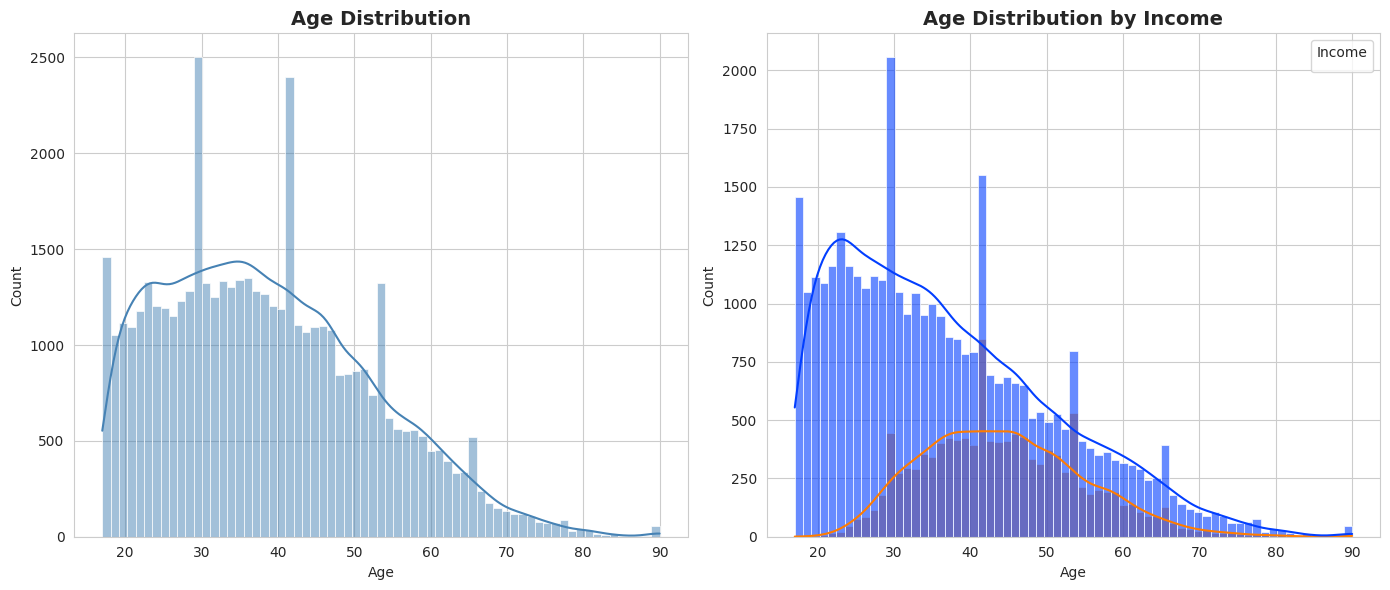

In [54]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style('whitegrid')
sns.histplot(data=df, x='age', kde=True, ax=axis[0], color='steelblue')
axis[0].set_title('Age Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Age')
axis[0].set_ylabel('Count')
sns.histplot(data=df, x='age', hue='income', kde=True, ax=axis[1], palette='bright', alpha=0.6)
axis[1].set_title('Age Distribution by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Age')
axis[1].set_ylabel('Count')
axis[1].legend(title='Income')
plt.tight_layout()
plt.show()


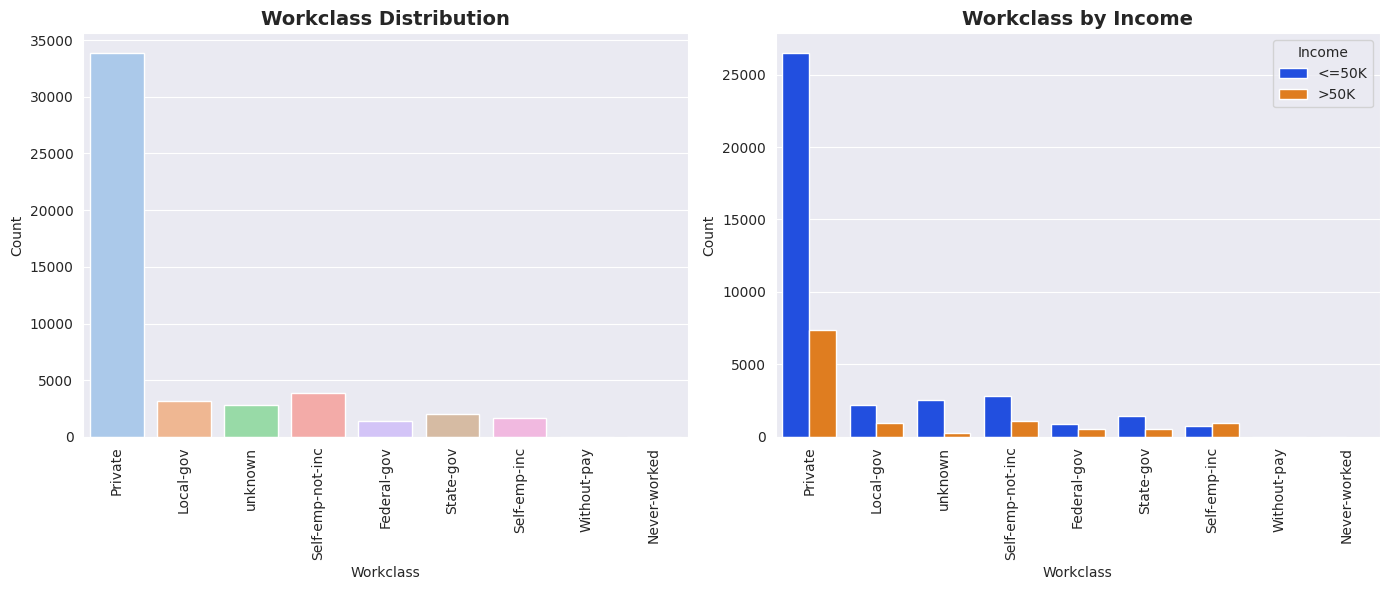

In [34]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style('darkgrid')
sns.countplot(data=df, x='workclass', ax=axis[0], palette='pastel')
axis[0].set_title('Workclass Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Workclass')
axis[0].set_ylabel('Count')
axis[0].tick_params(axis='x', rotation=90)
sns.countplot(data=df, x='workclass', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Workclass by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Workclass')
axis[1].set_ylabel('Count')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Income')
plt.tight_layout()
plt.show()

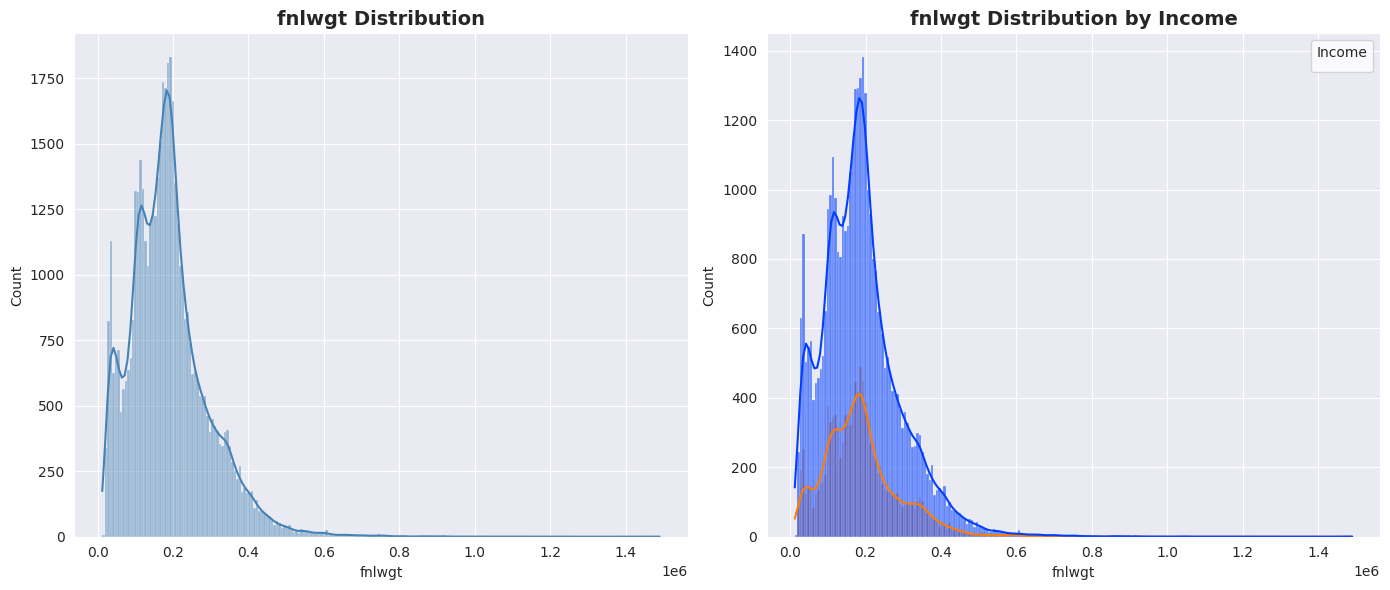

In [35]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style('whitegrid')

sns.histplot(data=df, x='fnlwgt', kde=True, ax=axis[0], color='steelblue')
axis[0].set_title('fnlwgt Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('fnlwgt')
axis[0].set_ylabel('Count')

sns.histplot(data=df, x='fnlwgt', hue='income', kde=True, ax=axis[1], palette='bright', alpha=0.6)
axis[1].set_title('fnlwgt Distribution by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('fnlwgt')
axis[1].set_ylabel('Count')
axis[1].legend(title='Income')

plt.tight_layout()
plt.show()


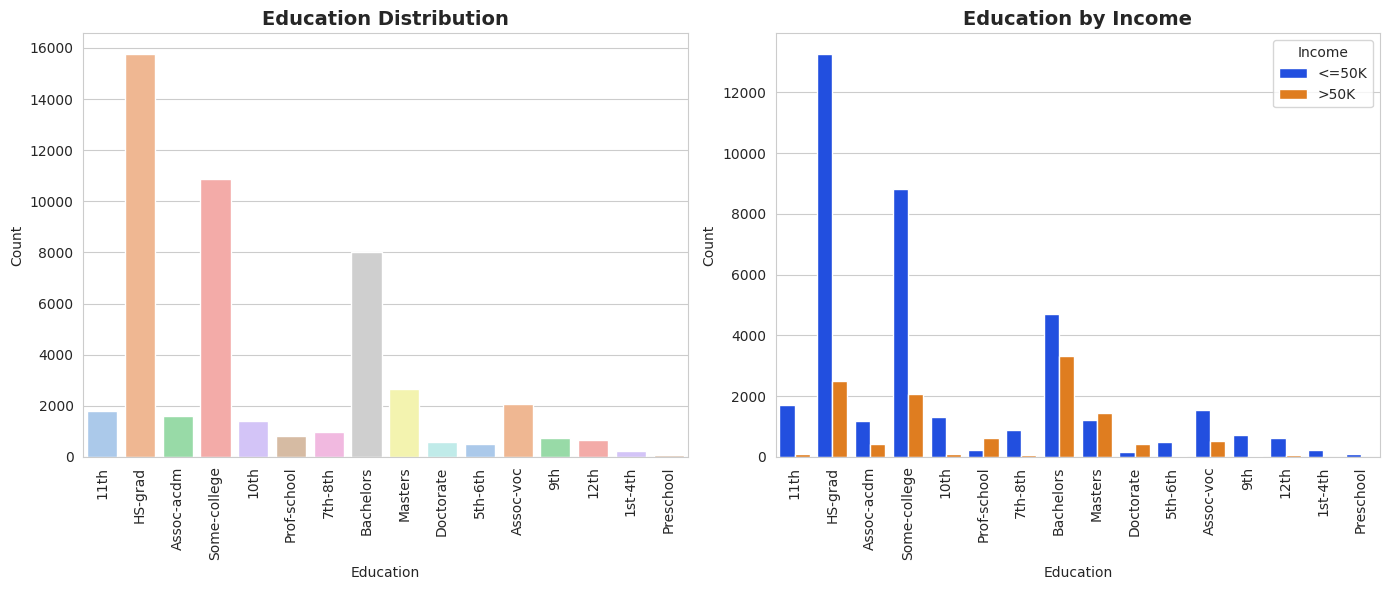

In [36]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style('whitegrid')

sns.countplot(data=df, x='education', ax=axis[0], palette='pastel')
axis[0].set_title('Education Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Education')
axis[0].set_ylabel('Count')
axis[0].tick_params(axis='x', rotation=90)

sns.countplot(data=df, x='education', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Education by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Education')
axis[1].set_ylabel('Count')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Income')

plt.tight_layout()
plt.show()


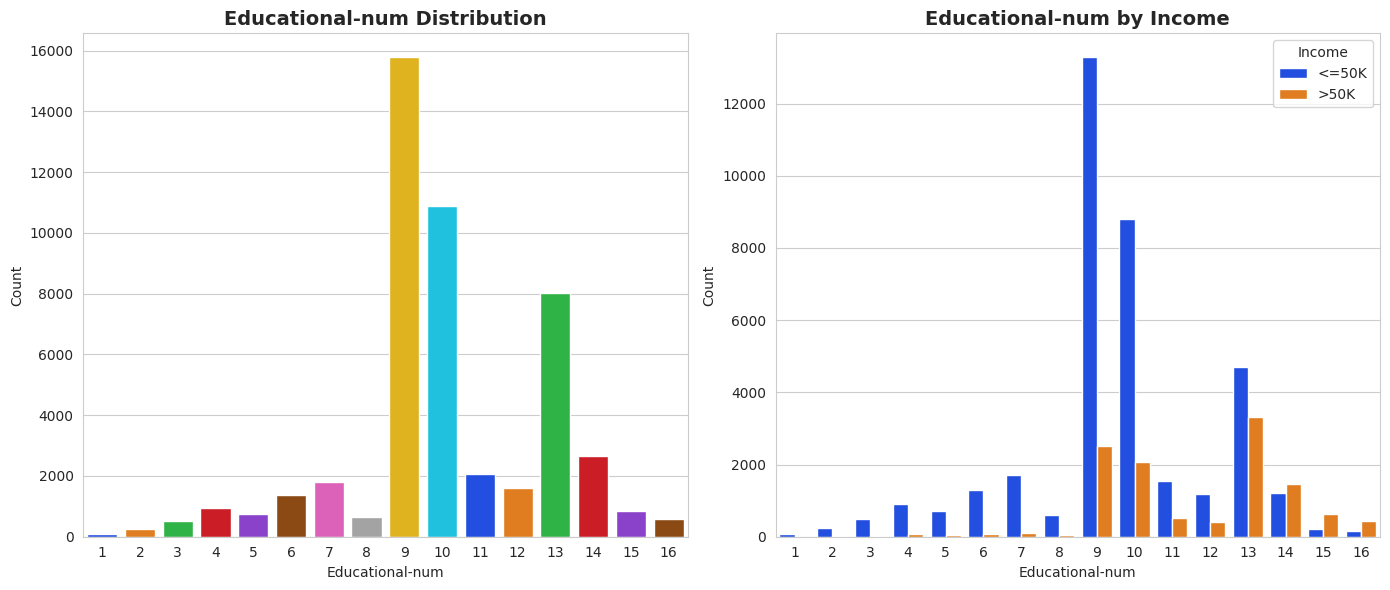

In [41]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, x='educational-num', ax=axis[0], palette='bright')
axis[0].set_title('Educational-num Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Educational-num')
axis[0].set_ylabel('Count')

sns.countplot(data=df, x='educational-num', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Educational-num by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Educational-num')
axis[1].set_ylabel('Count')
axis[1].legend(title='Income')

plt.tight_layout()
plt.show()


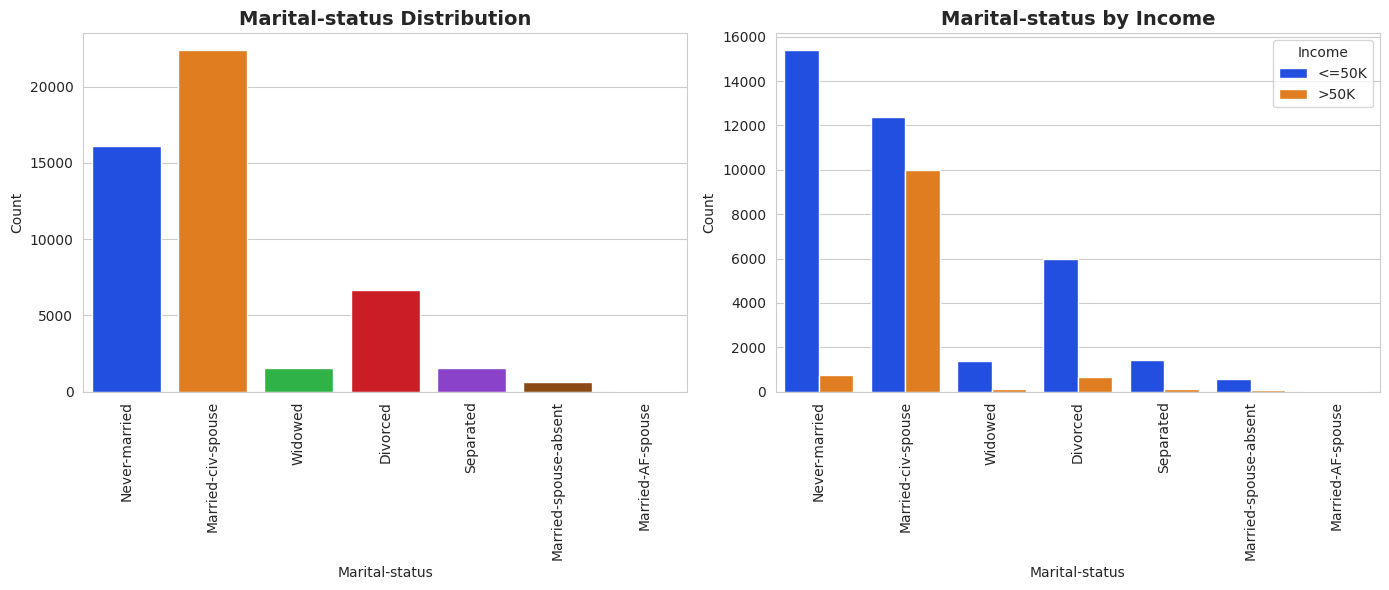

In [44]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=df, x='marital-status', ax=axis[0], palette='bright')
axis[0].set_title('Marital-status Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Marital-status')
axis[0].set_ylabel('Count')
axis[0].tick_params(axis='x', rotation=90)
sns.countplot(data=df, x='marital-status', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Marital-status by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Marital-status')
axis[1].set_ylabel('Count')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Income')
plt.tight_layout()
plt.show()


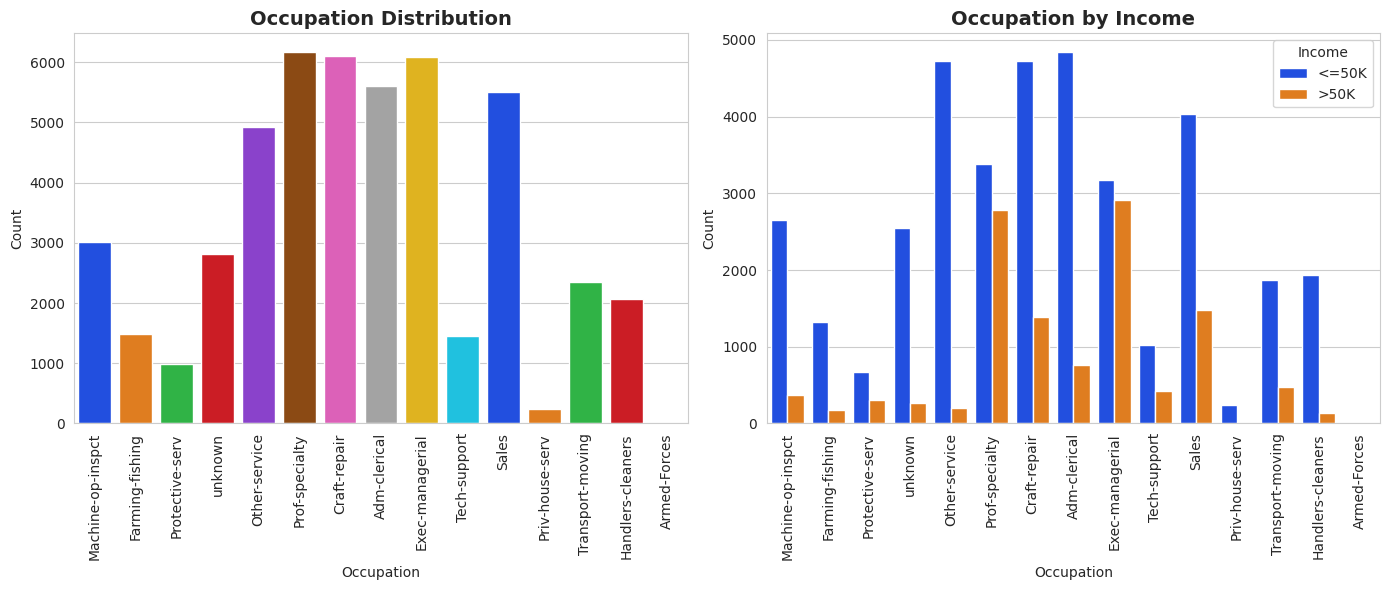

In [45]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=df, x='occupation', ax=axis[0], palette='bright')
axis[0].set_title('Occupation Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Occupation')
axis[0].set_ylabel('Count')
axis[0].tick_params(axis='x', rotation=90)

sns.countplot(data=df, x='occupation', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Occupation by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Occupation')
axis[1].set_ylabel('Count')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Income')

plt.tight_layout()
plt.show()


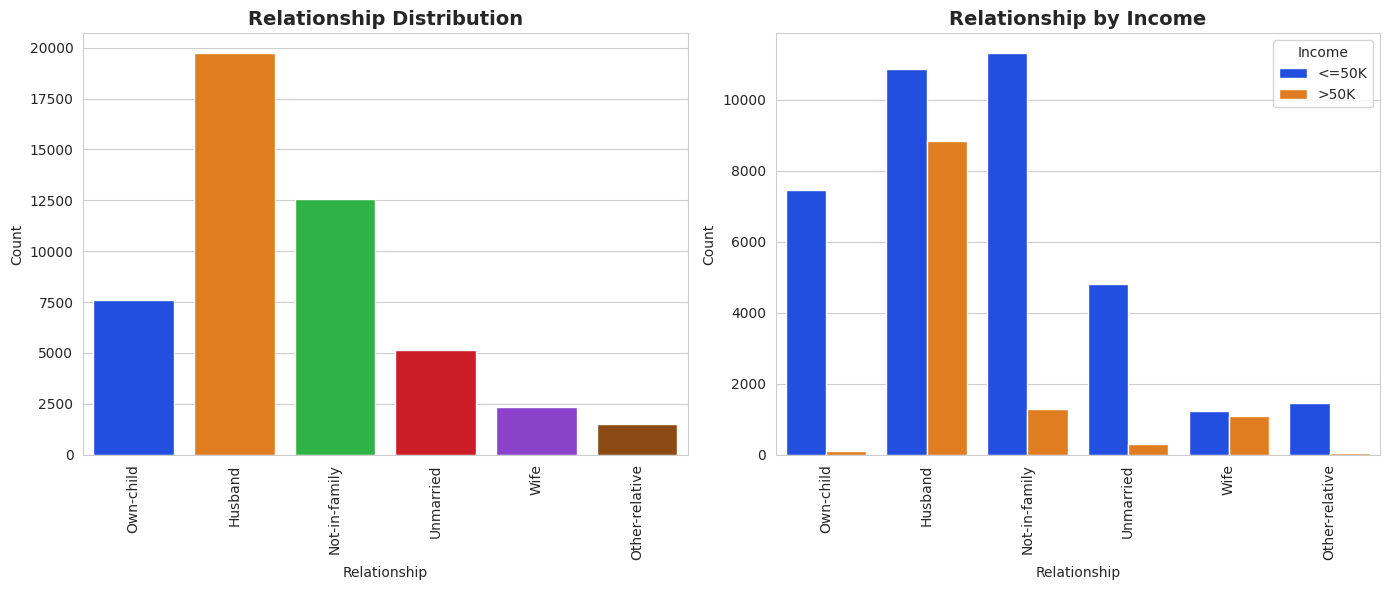

In [47]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=df, x='relationship', ax=axis[0], palette='bright')
axis[0].set_title('Relationship Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Relationship')
axis[0].set_ylabel('Count')
axis[0].tick_params(axis='x', rotation=90)
sns.countplot(data=df, x='relationship', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Relationship by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Relationship')
axis[1].set_ylabel('Count')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Income')
plt.tight_layout()
plt.show()

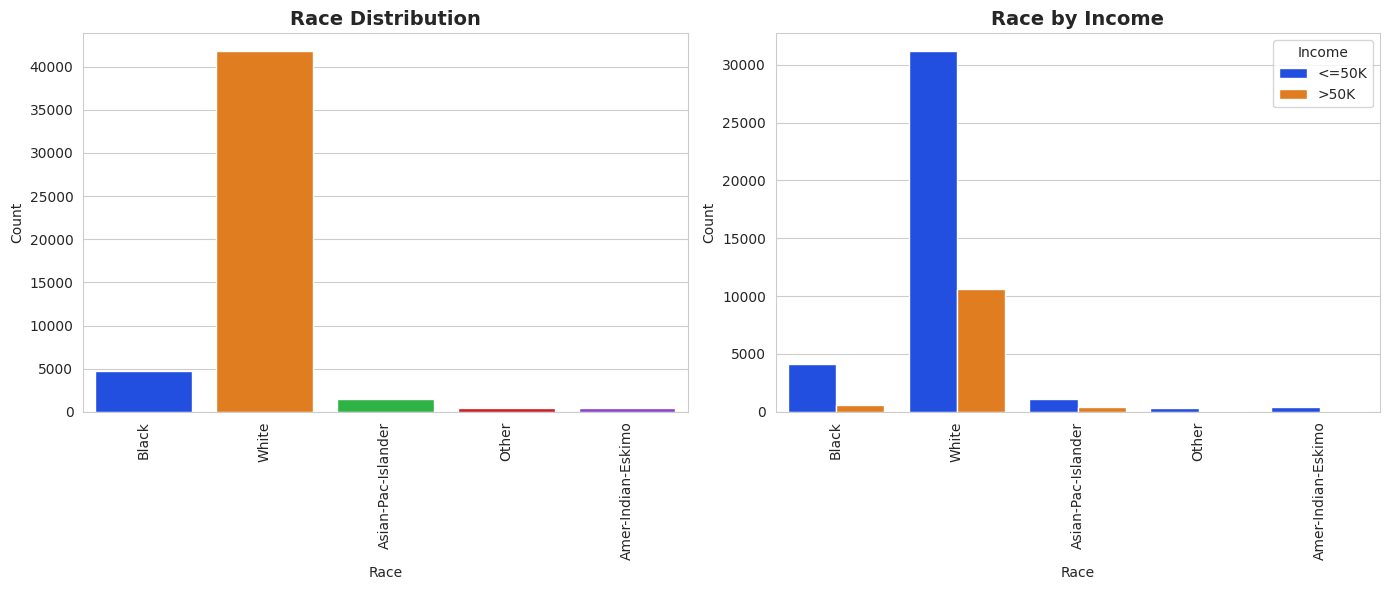

In [48]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=df, x='race', ax=axis[0], palette='bright')
axis[0].set_title('Race Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Race')
axis[0].set_ylabel('Count')
axis[0].tick_params(axis='x', rotation=90)
sns.countplot(data=df, x='race', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Race by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Race')
axis[1].set_ylabel('Count')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Income')
plt.tight_layout()
plt.show()

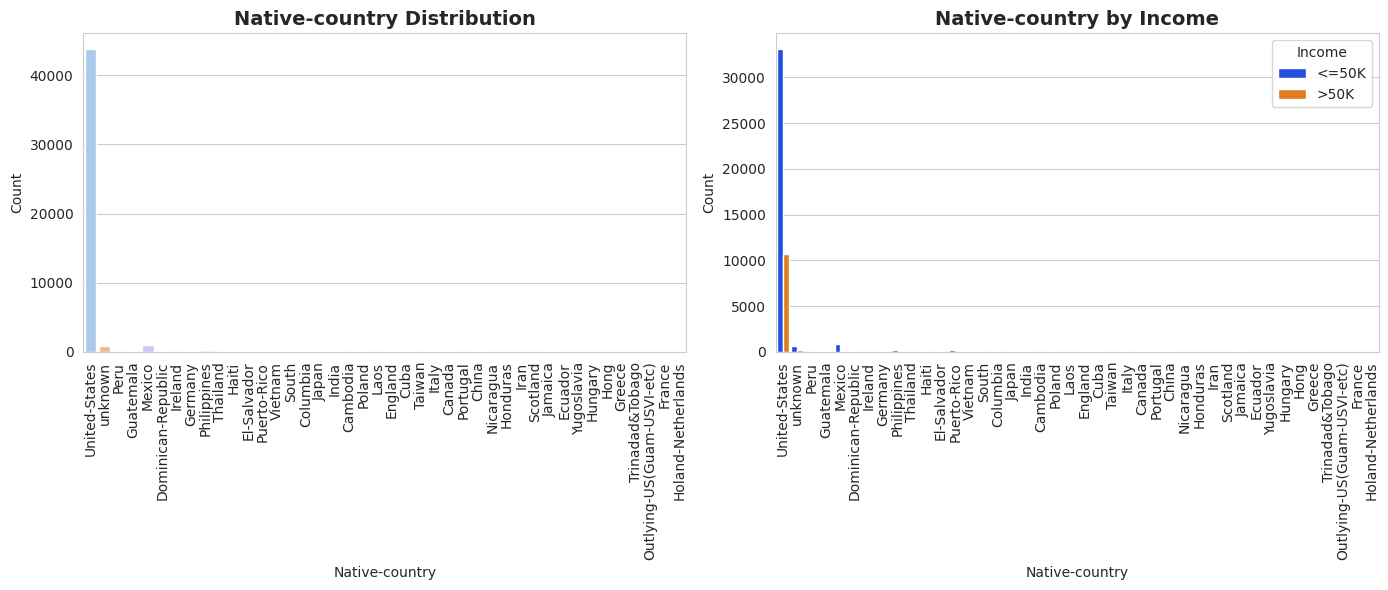

In [50]:
fig, axis = plt.subplots(1, 2, figsize=(14, 6))
sns.set_style('whitegrid')

sns.countplot(data=df, x='native-country', ax=axis[0], palette='pastel')
axis[0].set_title('Native-country Distribution', fontsize=14, fontweight='bold')
axis[0].set_xlabel('Native-country')
axis[0].set_ylabel('Count')
axis[0].tick_params(axis='x', rotation=90)

sns.countplot(data=df, x='native-country', hue='income', ax=axis[1], palette='bright')
axis[1].set_title('Native-country by Income', fontsize=14, fontweight='bold')
axis[1].set_xlabel('Native-country')
axis[1].set_ylabel('Count')
axis[1].tick_params(axis='x', rotation=90)
axis[1].legend(title='Income')

plt.tight_layout()
plt.show()


SyntaxError: invalid character '≥' (U+2265) (871617614.py, line 11)

<div style="
    background: linear-gradient(to bottom right, purple, cyan);
    padding: 20px;
    border-radius: 10px;
    color: white;
    font-family: Arial, sans-serif;
">

# **📊 Exploratory Data Analysis (EDA) Summary**

---

## **👤 Age**
- The **age distribution** is right-skewed, with a large number of younger individuals.
- **Income ≥ 50K**: Many young people also fall into this category.
- **Income < 50K**: Distribution is closer to normal.
  
---

## **🏢 Work Class**
- Most people work in the **Private sector**.
- **Income < 50K** dominates in this group, though a fair share earns ≥ 50K.
- Ratio of high to low earners in the private sector is **moderately good**.

---

## **🎓 Education**
- Dominated by **High School graduates**, **Some College**, and **Bachelor's degrees**.
- Very few individuals from **Pre-school** or **1st–4th grade** backgrounds.
- **High School** and **Some College** groups have a **balanced ratio** of both income classes.
- **Bachelor's** degree holders have a **slightly weaker ratio** compared to others.

---

## **💍 Marital Status**
- Major categories: **Married** and **Unmarried**.
- Also includes **Separated** and **Divorced**.
- **Unmarried individuals** show a **much better high-income ratio** than married couples.
- Married couples have an estimated **80:20 low-to-high income ratio**.

---

## **💼 Occupation**
- Well-distributed across various sectors:
  - **Sales**, **Executive/Managerial**, **Admin/Clerical**, **Craft/Repair**, **Other Services**.
- **Other Services** show a **good high-income ratio**.
- **Executive/Managerial** roles have **almost equal numbers** in both income groups.

---

## **🏠 Relationship**
- Common: **Husband** and **Not-in-family** categories.
- **Husbands** have an almost **50:50** high-to-low income ratio.
- **Not-in-family** individuals show a **stronger high-income presence**.

---

## **🌎 Race**
- Mostly **White**, followed by **Black**.
- Both groups have **similar income ratios**.

---

## **🗺️ Native Country**
- Over **95%** are from the **United States**.
- Few individuals from **Mexico** and other countries.
- Country distribution closely reflects **U.S.-centric data**.

</div>
